In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('dataa.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])
df['Дата']

0        2018-01-04
1        2018-01-04
2        2018-01-04
3        2018-01-04
4        2018-01-04
            ...    
301350   2018-08-31
301351   2018-08-31
301352   2018-08-31
301353   2018-08-31
301354   2018-08-31
Name: Дата, Length: 301355, dtype: datetime64[ns]

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

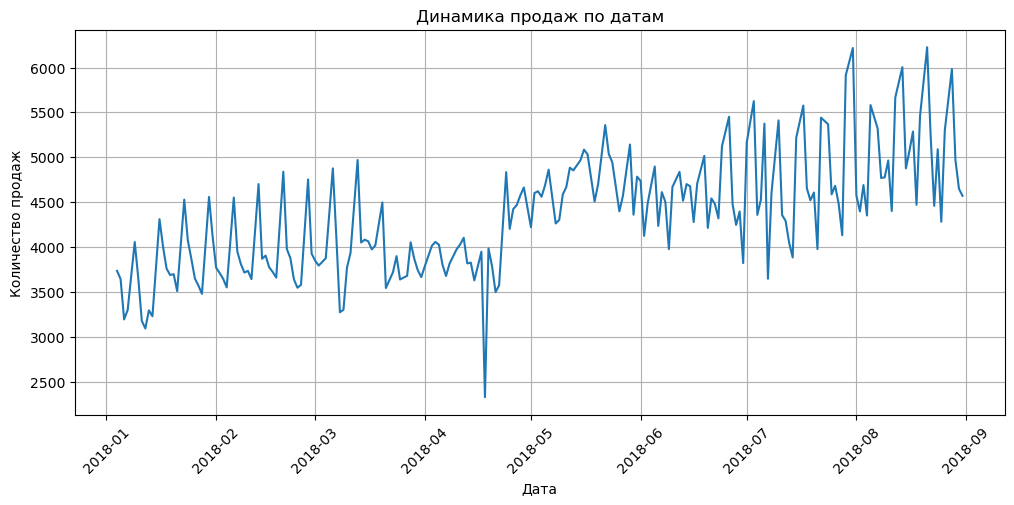

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [9]:
# На графике показана динамика количества продаж по датам. Видно, что продажи меняются неравномерно: в одни дни наблюдаются более высокие значения, 
# в другие — более низкие. Это может говорить о колебаниях спроса. Также на графике можно заметить отдельные пики, которые могут быть связаны с 
# повышенной активностью покупателей или крупными заказами.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

In [11]:
max_row = df.loc[df['Количество'].idxmax()]
max_row

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [13]:
df_3 = df[df['Склад'] == 3]
df_3

,Дата,Склад,Контрагент,Номенклатура,Количество
796,2018-01-04,3,address_79,product_0,0
797,2018-01-04,3,address_79,product_1,5
798,2018-01-04,3,address_79,product_2,3
799,2018-01-04,3,address_79,product_3,2
800,2018-01-04,3,address_79,product_4,2
...,...,...,...,...,...
300873,2018-08-31,3,address_112,product_2,4
300874,2018-08-31,3,address_112,product_3,3
300875,2018-08-31,3,address_112,product_4,2
300876,2018-08-31,3,address_112,product_5,1


In [14]:
df_summer = df_3[df_3['Дата'].dt.month.isin([6, 7, 8])]
df_summer

,Дата,Склад,Контрагент,Номенклатура,Количество
185268,2018-06-01,3,address_186,product_0,4
185269,2018-06-01,3,address_186,product_1,6
185270,2018-06-01,3,address_186,product_2,6
185271,2018-06-01,3,address_186,product_3,2
185272,2018-06-01,3,address_186,product_4,2
...,...,...,...,...,...
300873,2018-08-31,3,address_112,product_2,4
300874,2018-08-31,3,address_112,product_3,3
300875,2018-08-31,3,address_112,product_4,2
300876,2018-08-31,3,address_112,product_5,1


In [15]:
df_wed = df_summer[df_summer['Дата'].dt.dayofweek == 2]
df_wed

,Дата,Склад,Контрагент,Номенклатура,Количество
191165,2018-06-06,3,address_206,product_0,2
191166,2018-06-06,3,address_206,product_1,4
191167,2018-06-06,3,address_206,product_2,4
191168,2018-06-06,3,address_206,product_3,2
191169,2018-06-06,3,address_206,product_4,1
...,...,...,...,...,...
298028,2018-08-29,3,address_112,product_2,3
298029,2018-08-29,3,address_112,product_3,3
298030,2018-08-29,3,address_112,product_4,2
298031,2018-08-29,3,address_112,product_5,1


In [16]:
top_products = df_wed.groupby('Номенклатура')['Количество'].sum().reset_index()

In [17]:
top_products = top_products.sort_values('Количество', ascending=False)
top_products.head()

,Номенклатура,Количество
1,product_1,2267
12,product_2,2060
0,product_0,1324
17,product_3,914
20,product_6,650


In [18]:
top_products.iloc[0]

Номенклатура    product_1
Количество           2267
Name: 1, dtype: object

In [19]:
df_3 = df[df['Склад'] == 3]
df_summer = df_3[df_3['Дата'].dt.month.isin([6, 7, 8])]
df_wed = df_summer[df_summer['Дата'].dt.dayofweek == 2]

top_products = df_wed.groupby('Номенклатура')['Количество'].sum().reset_index()
top_products = top_products.sort_values('Количество', ascending=False)

top_products.head()

,Номенклатура,Количество
1,product_1,2267
12,product_2,2060
0,product_0,1324
17,product_3,914
20,product_6,650


In [20]:
# Среди товаров 3 склада, проданных по средам в июне, июле и августе, наибольший объем продаж показал товар product_1

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [21]:
print("Начало:", df['Дата'].min())
print("Конец:", df['Дата'].max())

Начало: 2018-01-04 00:00:00
Конец: 2018-08-31 00:00:00


In [48]:
weather_df = pd.read_csv('weather.csv', sep=';', skiprows=6)
weather_df = weather_df.reset_index()
weather_df.head()

,index,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [49]:
print(weather_df.columns)

Index(['index', 'Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD',
       'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H',
       'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')


In [50]:
weather_df = weather_df[['index', 'Местное время в Астане']]
weather_df.head()

,index,Местное время в Астане
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [51]:
weather_df = weather_df.rename(columns={'index': 'Дата', 'Местное время в Астане': 'T'})
weather_df.head()

,Дата,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [52]:
weather_df['Дата'] = weather_df['Дата'].astype(str).str.split(' ').str[0]
weather_df['Дата'] = pd.to_datetime(weather_df['Дата'], format='%d.%m.%Y')
weather_df.head()

,Дата,T
0,2018-08-31,8.2
1,2018-08-31,9.6
2,2018-08-31,11.3
3,2018-08-31,12.3
4,2018-08-31,13.2


In [53]:
weather_df['T'] = pd.to_numeric(weather_df['T'], errors='coerce')
weather_df.head()

,Дата,T
0,2018-08-31,8.2
1,2018-08-31,9.6
2,2018-08-31,11.3
3,2018-08-31,12.3
4,2018-08-31,13.2


In [54]:
weather_daily = weather_df.groupby('Дата')['T'].mean().reset_index()
weather_daily.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [55]:
merged_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')
merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


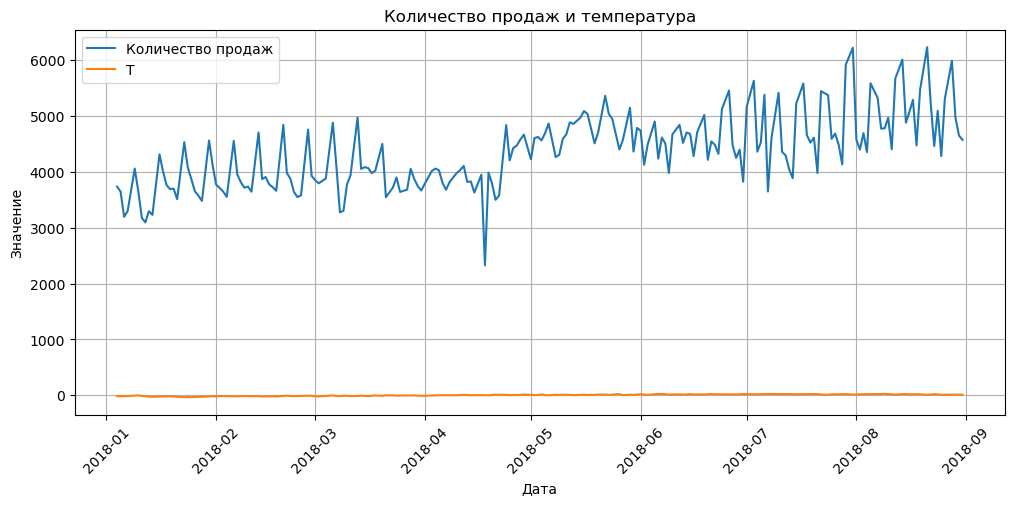

In [56]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df['Дата'], merged_df['Количество'], label='Количество продаж')
plt.plot(merged_df['Дата'], merged_df['T'], label='T')
plt.title('Количество продаж и температура')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

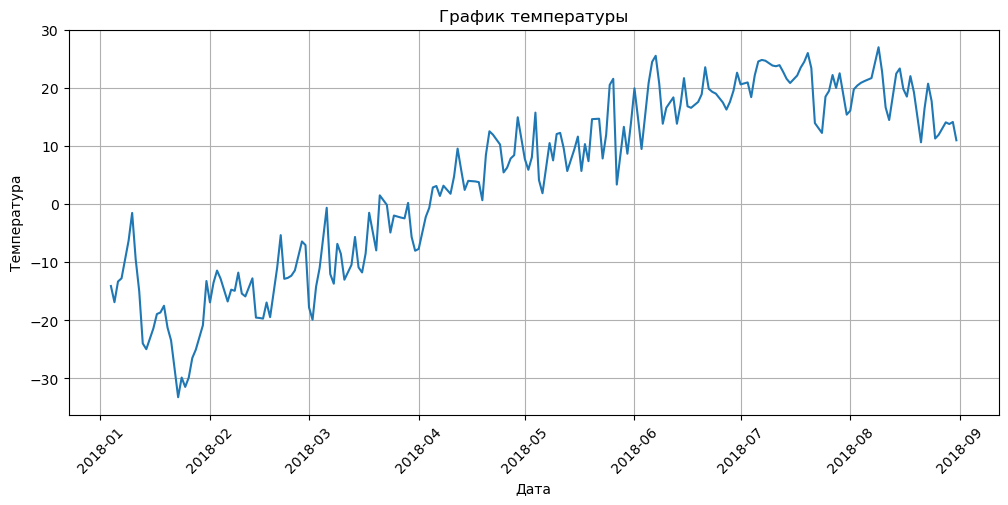

In [57]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df['Дата'], merged_df['T'])
plt.title('График температуры')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.xticks(rotation=45)
plt.grid()
plt.show()

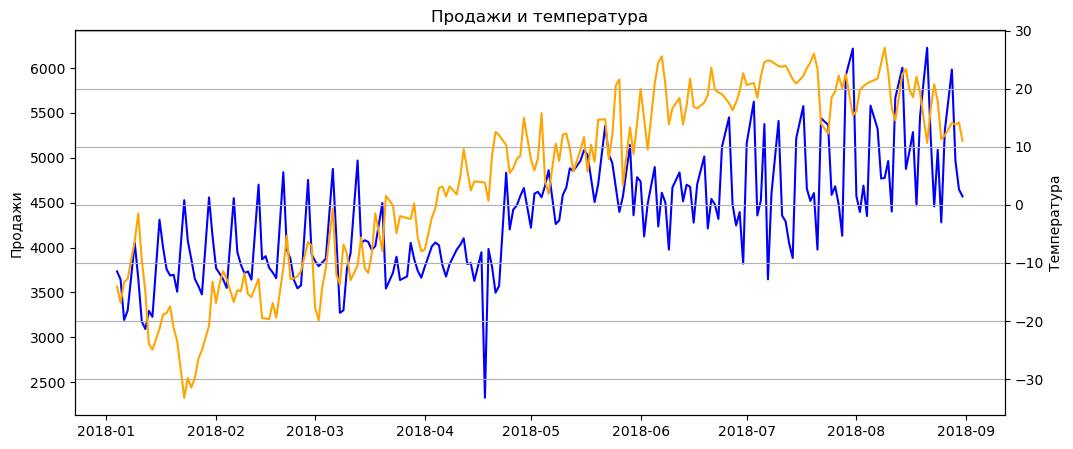

In [58]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(merged_df['Дата'], merged_df['Количество'], color='blue', label='Продажи')
ax1.set_ylabel('Продажи')

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], color='orange', label='Температура')
ax2.set_ylabel('Температура')

plt.title('Продажи и температура')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [59]:
# Данные по погоде были загружены и обработаны.
# Из таблицы были оставлены дата и температура, после чего рассчитана средняя температура за день.
# Далее погодные данные были объединены с grouped_df по столбцу Дата.
# Построены два графика:
# 1) Количество продаж и температура
# 2) Отдельный график температуры